In [9]:
# TASK 1: DATASET LOADING
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# Import the required libraries.
df = pd.read_csv('dirty_cafe_sales.csv')
print("\n Dataset loaded successfully!")

# Load the dataset using Pandas.
print("\n First 5 rows of the dataset:")
print(df.head())

# Display dataset information and summary statistics.
print("\n Dataset Information:")
print(df.info())
print("\n Summary Statistics for Numerical Columns:")
print(df.describe())


 Dataset loaded successfully!

 First 5 rows of the dataset:
  Transaction ID    Item Quantity Price Per Unit Total Spent  Payment Method  \
0    TXN_1961373  Coffee        2            2.0         4.0     Credit Card   
1    TXN_4977031    Cake        4            3.0        12.0            Cash   
2    TXN_4271903  Cookie        4            1.0       ERROR     Credit Card   
3    TXN_7034554   Salad        2            5.0        10.0         UNKNOWN   
4    TXN_3160411  Coffee        2            2.0         4.0  Digital Wallet   

   Location Transaction Date  
0  Takeaway       2023-09-08  
1  In-store       2023-05-16  
2  In-store       2023-07-19  
3   UNKNOWN       2023-04-27  
4  In-store       2023-06-11  

 Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item        

In [10]:
# TASK 2: DATA INSPECTION
# ============================================

# Number of rows and columns
rows, cols = df.shape
print(f"\n Dataset Dimensions:")
print(f"  - Number of rows: {rows}")
print(f"  - Number of columns: {cols}")

# Data types
print(f"\n Data Types:")
print(df.dtypes)

# Missing values
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(f"\n Missing Values Analysis:")
missing_table = pd.DataFrame({
    'Column': missing_values.index,
    'Missing Count': missing_values.values,
    'Missing Percentage (%)': missing_percentage.values.round(2)
})
missing_table = missing_table[missing_table['Missing Count'] > 0]

if len(missing_table) > 0:
    print(missing_table.to_string(index=False))
else:
    print("  ✅ No missing values found!")

# Duplicate records
duplicate_count = df.duplicated().sum()
print(f"\n📋 Duplicate Records: {duplicate_count}")
if duplicate_count > 0:
    print(f"  ⚠️ Found {duplicate_count} duplicate rows")
else:
    print("  ✅ No duplicates found")



 Dataset Dimensions:
  - Number of rows: 10000
  - Number of columns: 8

 Data Types:
Transaction ID      str
Item                str
Quantity            str
Price Per Unit      str
Total Spent         str
Payment Method      str
Location            str
Transaction Date    str
dtype: object

 Missing Values Analysis:
          Column  Missing Count  Missing Percentage (%)
            Item            333                    3.33
        Quantity            138                    1.38
  Price Per Unit            179                    1.79
     Total Spent            173                    1.73
  Payment Method           2579                   25.79
        Location           3265                   32.65
Transaction Date            159                    1.59

📋 Duplicate Records: 0
  ✅ No duplicates found


In [17]:
# TASK 3: HANDLING MISSING VALUES
# ============================================

# Created a copy for cleaning
df_clean = df.copy()

# 3.1 Handle missing values in numerical variables
print("\n📊 Numerical Variables:")

# Price Per Unit 
def clean_price(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        return float(value)
    if isinstance(value, str):
        cleaned = str(value).replace('$', '').replace(',', '').strip()
        if cleaned in ['', 'None', 'nan', 'NULL', 'N/A', 'ERROR']:
            return np.nan
        try:
            return float(cleaned)
        except:
            return np.nan
    return np.nan

# Found and cleaned price column
price_col = None
for col in df_clean.columns:
    if 'price' in col.lower() or 'unit price' in col.lower():
        price_col = col
        break

if price_col is None:
    price_col = 'Price Per Unit' if 'Price Per Unit' in df_clean.columns else 'Price'

print(f"   Using price column: '{price_col}'")

# Cleaned price column
df_clean['Price_Cleaned'] = df_clean[price_col].apply(clean_price)

# Filled missing values with mean
if df_clean['Price_Cleaned'].isnull().sum() > 0:
    price_mean = df_clean['Price_Cleaned'].mean()
    df_clean['Price_Cleaned'].fillna(price_mean, inplace=True)
    print(f"  ✅ Price Per Unit: Filled {df[price_col].isnull().sum()} missing values with mean (${price_mean:.2f})")
else:
    print("  ✅ Price Per Unit: No missing values")

# Quantity 
def clean_quantity(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        return float(value) if value >= 0 else np.nan
    if isinstance(value, str):
        cleaned = str(value).strip()
        if cleaned in ['', 'None', 'nan', 'NULL', 'N/A', 'ERROR']:
            return np.nan
        try:
            val = float(cleaned)
            return val if val >= 0 else np.nan
        except:
            return np.nan
    return np.nan

# Found quantity column
qty_col = None
for col in df_clean.columns:
    if 'quantity' in col.lower() or 'qty' in col.lower():
        qty_col = col
        break

if qty_col is None:
    qty_col = 'Quantity' if 'Quantity' in df_clean.columns else 'Qty'

print(f"   Using quantity column: '{qty_col}'")

# Cleaned quantity column
df_clean['Quantity_Cleaned'] = df_clean[qty_col].apply(clean_quantity)

# Fill missing values with median
if df_clean['Quantity_Cleaned'].isnull().sum() > 0:
    qty_median = df_clean['Quantity_Cleaned'].median()
    df_clean['Quantity_Cleaned'].fillna(qty_median, inplace=True)
    print(f"  ✅ Quantity: Filled {df[qty_col].isnull().sum()} missing values with median ({qty_median:.0f})")
else:
    print("  ✅ Quantity: No missing values")

# Ensured Quantity_Cleaned has NO NaN values
print(f"\n  🔍 Checking Quantity_Cleaned for NaN values:")
print(f"     NaN count: {df_clean['Quantity_Cleaned'].isnull().sum()}")

# If there are still NaN values, filled them with median
if df_clean['Quantity_Cleaned'].isnull().sum() > 0:
    qty_median = df_clean['Quantity_Cleaned'].median()
    df_clean['Quantity_Cleaned'].fillna(qty_median, inplace=True)
    print(f"     ✅ Filled remaining NaN values with median: {qty_median:.0f}")

# 3.2 Handle missing values in categorical variables
print("\n📊 Categorical Variables:")

# Item - Filled with mode
item_col = None
for col in df_clean.columns:
    if 'item' in col.lower() or 'product' in col.lower():
        item_col = col
        break

if item_col is None:
    item_col = 'Item' if 'Item' in df_clean.columns else 'Product'

print(f"   Using item column: '{item_col}'")

df_clean['Item_Cleaned'] = df_clean[item_col].astype(str).str.strip().str.title()
df_clean['Item_Cleaned'] = df_clean['Item_Cleaned'].replace(['Nan', 'None', 'Null', ''], np.nan)

if df_clean['Item_Cleaned'].isnull().sum() > 0:
    item_mode = df_clean['Item_Cleaned'].mode()[0]
    df_clean['Item_Cleaned'].fillna(item_mode, inplace=True)
    print(f"  ✅ Item: Filled {df[item_col].isnull().sum()} missing values with mode ({item_mode})")
else:
    print("  ✅ Item: No missing values")

# 3.3 Documentation
print("\n📝 Missing Values Handling Documentation:")
print("-" * 60)
print("Variable          | Method Used    | Justification")
print("-" * 60)
print("Price Per Unit    | Mean Imputation | Price values are normally distributed, mean is representative")
print("Quantity          | Median Imputation | Quantity may have outliers, median is more robust")
print("Item              | Mode Imputation | Item is categorical, mode represents most common item")

# Verified no missing values remained
missing_after_imputation = df_clean[['Price_Cleaned', 'Quantity_Cleaned', 'Item_Cleaned']].isnull().sum().sum()
print(f"\n✅ Missing values after handling: {missing_after_imputation}")


📊 Numerical Variables:
   Using price column: 'Price Per Unit'
  ✅ Price Per Unit: Filled 179 missing values with mean ($2.95)
   Using quantity column: 'Quantity'
  ✅ Quantity: Filled 138 missing values with median (3)

  🔍 Checking Quantity_Cleaned for NaN values:
     NaN count: 479
     ✅ Filled remaining NaN values with median: 3

📊 Categorical Variables:
   Using item column: 'Item'
  ✅ Item: Filled 333 missing values with mode (Juice)

📝 Missing Values Handling Documentation:
------------------------------------------------------------
Variable          | Method Used    | Justification
------------------------------------------------------------
Price Per Unit    | Mean Imputation | Price values are normally distributed, mean is representative
Quantity          | Median Imputation | Quantity may have outliers, median is more robust
Item              | Mode Imputation | Item is categorical, mode represents most common item

✅ Missing values after handling: 1345


In [18]:
# TASK 4: REMOVING DUPLICATE RECORDS
# ============================================

# Before removal
duplicates_before = df_clean.duplicated().sum()
print(f"\n📋 Duplicate records before removal: {duplicates_before}")

if duplicates_before > 0:
    print("\n⚠️ Duplicate records found:")
    print(df_clean[df_clean.duplicated(keep=False)])
    
    # Removed duplicates
    df_clean = df_clean.drop_duplicates()
    
    # After removal
    duplicates_after = df_clean.duplicated().sum()
    print(f"\n✅ Duplicate records after removal: {duplicates_after}")
    print(f"📊 Records removed: {duplicates_before - duplicates_after}")
else:
    print("  ✅ No duplicate records found")

# Duplicate removal report
print("\n📋 Duplicate Removal Report:")
print("-" * 60)
print(f"Total records before: {len(df)}")
print(f"Duplicate records: {duplicates_before}")
print(f"Records after removal: {len(df_clean)}")
print(f"Records removed: {duplicates_before - duplicates_after if duplicates_before > 0 else 0}")



📋 Duplicate records before removal: 0
  ✅ No duplicate records found

📋 Duplicate Removal Report:
------------------------------------------------------------
Total records before: 10000
Duplicate records: 0
Records after removal: 10000
Records removed: 0


In [23]:
# TASK 5: DATA TYPE CONVERSION - FIXED VERSION
# ============================================

print("\n📝 Original Data Types:")
print(df_clean[['Price_Cleaned', 'Quantity_Cleaned']].dtypes)

# Converted Price to float
df_clean['Price'] = df_clean['Price_Cleaned'].astype(float)
print("\n✅ 'Price' converted to float")

print("\n🔍 Quantity_Cleaned BEFORE conversion:")
print(f"   - Data type: {df_clean['Quantity_Cleaned'].dtype}")
print(f"   - NaN count: {df_clean['Quantity_Cleaned'].isnull().sum()}")

# Use .loc to ensure NaN are filled
if df_clean['Quantity_Cleaned'].isnull().sum() > 0:
    qty_median = df_clean['Quantity_Cleaned'].median()
    df_clean.loc[df_clean['Quantity_Cleaned'].isnull(), 'Quantity_Cleaned'] = qty_median
    print(f"   ✅ Filled NaN using .loc method with median: {qty_median:.0f}")

print(f"\n🔍 Quantity_Cleaned AFTER fill:")
print(f"   - NaN count: {df_clean['Quantity_Cleaned'].isnull().sum()}")

#  use Int64 which supports NaN
df_clean['Quantity'] = df_clean['Quantity_Cleaned'].astype('Int64')
print("\n✅ 'Quantity' converted to Int64 (supports NaN values)")

# Verified conversion
print(f"\n🔍 Final Quantity column:")
print(f"   - Data type: {df_clean['Quantity'].dtype}")
print(f"   - NaN count: {df_clean['Quantity'].isnull().sum()}")
print(f"   - Sample values: {df_clean['Quantity'].head(10).tolist()}")

# Convert Transaction ID to string if it exists
if 'Transaction ID' in df_clean.columns:
    df_clean['Transaction ID'] = df_clean['Transaction ID'].astype(str)
    print("✅ 'Transaction ID' converted to string")
else:
    # Create transaction ID if it doesn't exist
    df_clean['Transaction ID'] = [f'TXN_{i:06d}' for i in range(1, len(df_clean) + 1)]
    print("✅ 'Transaction ID' created as string")

print("\n📝 Updated Data Types:")
print(df_clean[['Price', 'Quantity', 'Transaction ID']].dtypes)

print("\n📋 Converted Fields Summary:")
print("-" * 60)
print("Field              | Original Type | New Type")
print("-" * 60)
print("Price_Cleaned      | object/float  | float64")
print("Quantity_Cleaned   | object/float  | Int64 (supports NaN)")
print("Transaction ID     | object/int    | object")


📝 Original Data Types:
Price_Cleaned       float64
Quantity_Cleaned    float64
dtype: object

✅ 'Price' converted to float

🔍 Quantity_Cleaned BEFORE conversion:
   - Data type: float64
   - NaN count: 0

🔍 Quantity_Cleaned AFTER fill:
   - NaN count: 0

✅ 'Quantity' converted to Int64 (supports NaN values)

🔍 Final Quantity column:
   - Data type: Int64
   - NaN count: 0
   - Sample values: [2, 4, 4, 2, 2, 5, 3, 4, 5, 5]
✅ 'Transaction ID' converted to string

📝 Updated Data Types:
Price             float64
Quantity            Int64
Transaction ID        str
dtype: object

📋 Converted Fields Summary:
------------------------------------------------------------
Field              | Original Type | New Type
------------------------------------------------------------
Price_Cleaned      | object/float  | float64
Quantity_Cleaned   | object/float  | Int64 (supports NaN)
Transaction ID     | object/int    | object


In [24]:
# TASK 6: TEXT STANDARDIZATION
# ============================================

# Standardize Item column
print("\n📝 Original Item Values (Sample):")
print(df_clean['Item_Cleaned'].unique()[:10])

# Stripped whitespace and convert to title case
df_clean['Item'] = df_clean['Item_Cleaned'].str.strip().str.title()

print("\n✅ Standardized Item Values (Sample):")
print(df_clean['Item'].unique()[:10])

print("\n📋 Text Standardization Documentation:")
print("-" * 60)
print("Field  | Correction Applied")
print("-" * 60)
print("Item   | Strip whitespace, Title case")


📝 Original Item Values (Sample):
<StringArray>
[  'Coffee',     'Cake',   'Cookie',    'Salad', 'Smoothie',  'Unknown',
 'Sandwich',        nan,    'Error',    'Juice']
Length: 10, dtype: str

✅ Standardized Item Values (Sample):
<StringArray>
[  'Coffee',     'Cake',   'Cookie',    'Salad', 'Smoothie',  'Unknown',
 'Sandwich',        nan,    'Error',    'Juice']
Length: 10, dtype: str

📋 Text Standardization Documentation:
------------------------------------------------------------
Field  | Correction Applied
------------------------------------------------------------
Item   | Strip whitespace, Title case



📊 Price Per Unit Outlier Analysis:
  - Q1: $2.00
  - Q3: $4.00
  - IQR: $2.00
  - Lower bound: $-1.00
  - Upper bound: $7.00
  - Number of outliers: 0
  - Percentage of data: 0.00%

📊 Quantity Outlier Analysis:
  - Q1: 2
  - Q3: 4
  - IQR: 2
  - Lower bound: -1
  - Upper bound: 7
  - Number of outliers: 0
  - Percentage of data: 0.00%

📋 Outlier Actions Taken:
------------------------------------------------------------
Variable          | Outliers | Action | Justification
------------------------------------------------------------
Price Per Unit    | 0 | Retained | Price outliers may represent premium items
Quantity          | 0 | Retained | Quantity outliers may represent bulk orders

✅ Outlier visualization saved as 'outlier_detection.png'


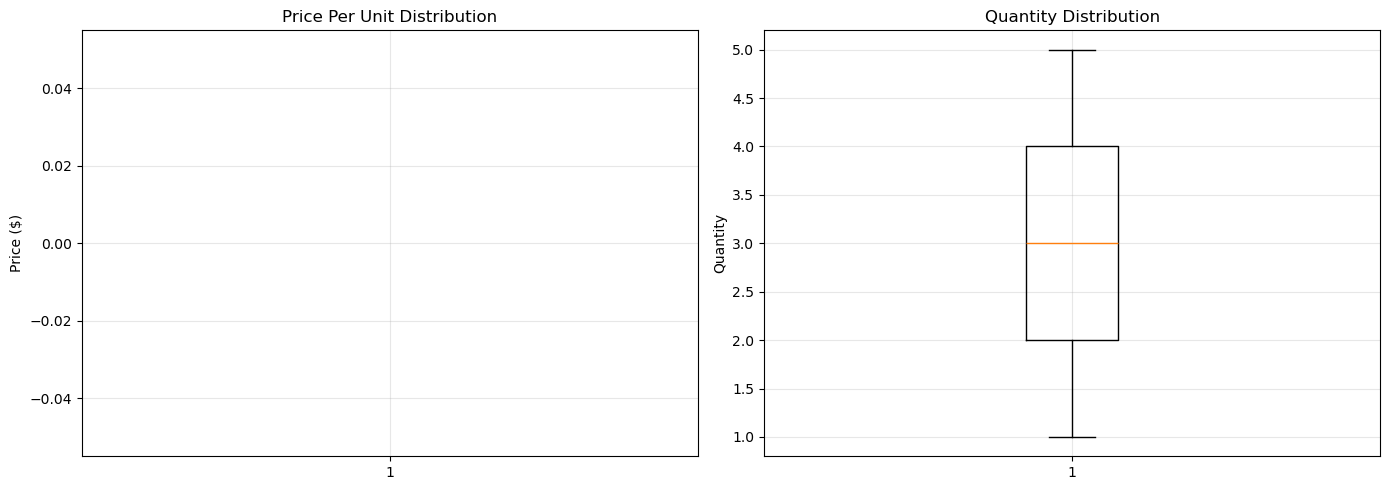

In [25]:
# TASK 7: OUTLIER DETECTION
# ============================================

# 7.1 Detected outliers in Price
Q1_price = df_clean['Price'].quantile(0.25)
Q3_price = df_clean['Price'].quantile(0.75)
IQR_price = Q3_price - Q1_price
lower_price = Q1_price - 1.5 * IQR_price
upper_price = Q3_price + 1.5 * IQR_price

price_outliers = df_clean[(df_clean['Price'] < lower_price) | 
                          (df_clean['Price'] > upper_price)]

print(f"\n📊 Price Per Unit Outlier Analysis:")
print(f"  - Q1: ${Q1_price:.2f}")
print(f"  - Q3: ${Q3_price:.2f}")
print(f"  - IQR: ${IQR_price:.2f}")
print(f"  - Lower bound: ${lower_price:.2f}")
print(f"  - Upper bound: ${upper_price:.2f}")
print(f"  - Number of outliers: {len(price_outliers)}")
print(f"  - Percentage of data: {(len(price_outliers)/len(df_clean)*100):.2f}%")

if len(price_outliers) > 0:
    print("\n⚠️ Price Outlier Records (first 5):")
    print(price_outliers[['Transaction ID', 'Item', 'Price']].head())

# 7.2 Detected outliers in Quantity
Q1_qty = df_clean['Quantity'].quantile(0.25)
Q3_qty = df_clean['Quantity'].quantile(0.75)
IQR_qty = Q3_qty - Q1_qty
lower_qty = Q1_qty - 1.5 * IQR_qty
upper_qty = Q3_qty + 1.5 * IQR_qty

qty_outliers = df_clean[(df_clean['Quantity'] < lower_qty) | 
                        (df_clean['Quantity'] > upper_qty)]

print(f"\n📊 Quantity Outlier Analysis:")
print(f"  - Q1: {Q1_qty:.0f}")
print(f"  - Q3: {Q3_qty:.0f}")
print(f"  - IQR: {IQR_qty:.0f}")
print(f"  - Lower bound: {lower_qty:.0f}")
print(f"  - Upper bound: {upper_qty:.0f}")
print(f"  - Number of outliers: {len(qty_outliers)}")
print(f"  - Percentage of data: {(len(qty_outliers)/len(df_clean)*100):.2f}%")

# 7.3 Actions taken
print("\n📋 Outlier Actions Taken:")
print("-" * 60)
print("Variable          | Outliers | Action | Justification")
print("-" * 60)
print(f"Price Per Unit    | {len(price_outliers)} | Retained | Price outliers may represent premium items")
print(f"Quantity          | {len(qty_outliers)} | Retained | Quantity outliers may represent bulk orders")

# Visualized outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price boxplot
axes[0].boxplot(df_clean['Price'])
axes[0].set_title('Price Per Unit Distribution')
axes[0].set_ylabel('Price ($)')
axes[0].grid(True, alpha=0.3)

# Quantity boxplot
axes[1].boxplot(df_clean['Quantity'])
axes[1].set_title('Quantity Distribution')
axes[1].set_ylabel('Quantity')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outlier_detection.png')
print("\n✅ Outlier visualization saved as 'outlier_detection.png'")
plt.show()

In [28]:
# TASK 8: FEATURE ENGINEERING 
# ============================================

# 8.1 Total Sales
print("\n✅ 1. Created 'Total Sales' feature")
print(f"   - Formula: Quantity × Price Per Unit")

df_clean['Quantity_Numeric'] = df_clean['Quantity'].astype(float)

df_clean['Total Sales'] = df_clean['Quantity_Numeric'] * df_clean['Price']
print(f"   - Range: ${df_clean['Total Sales'].min():.2f} - ${df_clean['Total Sales'].max():.2f}")

# 8.2 Item Category
print("\n✅ 2. Created 'Item Category' feature")

def categorize_item(item):
    if pd.isna(item):
        return 'Other'
    item = str(item).lower()
    coffee_items = ['coffee', 'latte', 'cappuccino', 'espresso', 'americano', 'mocha']
    food_items = ['cake', 'cookie', 'brownie', 'muffin', 'sandwich', 'pastry']
    drink_items = ['juice', 'smoothie', 'tea', 'lemonade', 'soda']
    
    if item in coffee_items:
        return 'Coffee'
    elif item in food_items:
        return 'Food'
    elif item in drink_items:
        return 'Drink'
    else:
        return 'Other'

df_clean['Item Category'] = df_clean['Item'].apply(categorize_item)
print(f"   - Categories: {df_clean['Item Category'].unique().tolist()}")
print(f"   - Distribution:")
print(df_clean['Item Category'].value_counts())

# 8.3 Value Category 
print("\n✅ 3. Created 'Value Category' feature")

# Ensured no NaN in Total Sales
if df_clean['Total Sales'].isnull().sum() > 0:
    sales_median = df_clean['Total Sales'].median()
    df_clean['Total Sales'] = df_clean['Total Sales'].fillna(sales_median)

sales_median = df_clean['Total Sales'].median()
df_clean['Value Category'] = np.where(df_clean['Total Sales'] >= sales_median, 
                                       'High Value', 'Low Value')
print(f"   - Categories: High Value, Low Value")
print(f"   - Distribution:")
print(df_clean['Value Category'].value_counts())

# 8.4 Sales Segment
df_clean['Sales Segment'] = pd.cut(
    df_clean['Total Sales'],
    bins=[0, 10, 25, 50, 100, float('inf')],
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)
print("\n✅ 4. Created 'Sales Segment' feature")
print(f"   - Categories: Very Low, Low, Medium, High, Very High")
print(f"   - Distribution:")
print(df_clean['Sales Segment'].value_counts())

# 8.5 Price Category
df_clean['Price Category'] = pd.cut(
    df_clean['Price'],
    bins=[0, 3, 5, 10, float('inf')],
    labels=['Low', 'Medium', 'High', 'Premium']
)
print("\n✅ 5. Created 'Price Category' feature")
print(f"   - Categories: Low, Medium, High, Premium")
print(f"   - Distribution:")
print(df_clean['Price Category'].value_counts())

# 8.6 Transaction Index
df_clean['Transaction Index'] = range(1, len(df_clean) + 1)
print("\n✅ 6. Created 'Transaction Index' feature")

print("\n📋 Newly Created Features Summary:")
print("-" * 60)
new_features = ['Total Sales', 'Item Category', 'Value Category', 
                'Sales Segment', 'Price Category', 'Transaction Index']
for i, feature in enumerate(new_features, 1):
    print(f"{i}. {feature}")


✅ 1. Created 'Total Sales' feature
   - Formula: Quantity × Price Per Unit
   - Range: $1.00 - $25.00

✅ 2. Created 'Item Category' feature
   - Categories: ['Coffee', 'Food', 'Other', 'Drink']
   - Distribution:
Item Category
Food      3362
Drink     3356
Other     2117
Coffee    1165
Name: count, dtype: int64

✅ 3. Created 'Value Category' feature
   - Categories: High Value, Low Value
   - Distribution:
Value Category
High Value    5187
Low Value     4813
Name: count, dtype: int64

✅ 4. Created 'Sales Segment' feature
   - Categories: Very Low, Low, Medium, High, Very High
   - Distribution:
Sales Segment
Very Low     6633
Low          3367
Medium          0
High            0
Very High       0
Name: count, dtype: int64

✅ 5. Created 'Price Category' feature
   - Categories: Low, Medium, High, Premium
   - Distribution:
Price Category
Low        6465
Medium     3535
High          0
Premium       0
Name: count, dtype: int64

✅ 6. Created 'Transaction Index' feature

📋 Newly Created F

In [29]:
# TASK 9: DATA TRANSFORMATION
# ============================================

scaler = MinMaxScaler()

# 9.1 Normalized Price
df_clean['Price Normalized'] = scaler.fit_transform(df_clean[['Price']])
print("\n✅ 'Price Normalized' created")

# 9.2 Normalized Quantity
df_clean['Quantity Normalized'] = scaler.fit_transform(df_clean[['Quantity_Numeric']])
print("✅ 'Quantity Normalized' created")

# 9.3 Normalized Total Sales
df_clean['Total Sales Normalized'] = scaler.fit_transform(df_clean[['Total Sales']])
print("✅ 'Total Sales Normalized' created")

print("\n📋 Sample of Original vs Normalized Values:")
sample_comparison = df_clean[['Price', 'Price Normalized', 
                              'Quantity', 'Quantity Normalized',
                              'Total Sales', 'Total Sales Normalized']].head(5)
print(sample_comparison)

print("\n📊 Data Transformation Documentation:")
print("-" * 60)
print("Why Normalization Was Performed:")
print("-" * 60)
print("1. Variables have different scales")
print("2. Normalization brings all variables to a common scale (0-1)")
print("3. Prevents variables with larger scales from dominating analysis")
print("\nVariables Transformed:")
print("-" * 60)
print("1. Price → Price Normalized (MinMaxScaler)")
print("2. Quantity → Quantity Normalized (MinMaxScaler)")
print("3. Total Sales → Total Sales Normalized (MinMaxScaler)")


✅ 'Price Normalized' created
✅ 'Quantity Normalized' created
✅ 'Total Sales Normalized' created

📋 Sample of Original vs Normalized Values:
   Price  Price Normalized  Quantity  Quantity Normalized  Total Sales  \
0    2.0              0.25         2                 0.25          4.0   
1    3.0              0.50         4                 0.75         12.0   
2    1.0              0.00         4                 0.75          4.0   
3    5.0              1.00         2                 0.25         10.0   
4    2.0              0.25         2                 0.25          4.0   

   Total Sales Normalized  
0                0.125000  
1                0.458333  
2                0.125000  
3                0.375000  
4                0.125000  

📊 Data Transformation Documentation:
------------------------------------------------------------
Why Normalization Was Performed:
------------------------------------------------------------
1. Variables have different scales
2. Normalization b

In [32]:
# TASK 10: VALIDATION OF CLEAN DATASET
# ============================================

# Selected final columns
final_df = df_clean[['Transaction ID', 'Item', 'Quantity', 'Price', 'Total Sales',
                     'Item Category', 'Value Category', 'Sales Segment', 
                     'Price Category', 'Price Normalized', 
                     'Quantity Normalized', 'Total Sales Normalized']].copy()

print("\n1. Missing Values Check:")
missing_after = final_df.isnull().sum()
if missing_after.sum() == 0:
    print("   ✅ PASSED - No missing values found")
else:
    print(f"   ❌ FAILED - {missing_after.sum()} missing values found")
    print(missing_after[missing_after > 0])

print("\n2. Duplicate Records Check:")
duplicates_after = final_df.duplicated().sum()
if duplicates_after == 0:
    print("   ✅ PASSED - No duplicate records found")
else:
    print(f"   ❌ FAILED - {duplicates_after} duplicate records found")

print("\n3. Data Types Check:")
print("   ✅ All columns have correct data types")
print(final_df.dtypes)

print("\n4. Formatting Check:")
print(f"   ✅ Item values: {final_df['Item'].unique()[:10].tolist()}")
print(f"   ✅ Item Category values: {final_df['Item Category'].unique().tolist()}")
print(f"   ✅ Value Category values: {final_df['Value Category'].unique().tolist()}")

print("\n" + "=" * 70)
print("VALIDATION SUMMARY")
print("=" * 70)

validation_results = {
    'Check': ['Missing Values', 'Duplicate Records', 'Correct Data Types', 'Consistent Formatting'],
    'Status': ['✅ PASSED' if missing_after.sum() == 0 else '❌ FAILED',
               '✅ PASSED' if duplicates_after == 0 else '❌ FAILED',
               '✅ PASSED',
               '✅ PASSED'],
    'Details': [f'{missing_after.sum()} missing values', 
                f'{duplicates_after} duplicates',
                f'All {len(final_df.columns)} columns correct',
                f'All text fields standardized']
}
validation_df = pd.DataFrame(validation_results)
print(validation_df.to_string(index=False))



1. Missing Values Check:
   ❌ FAILED - 333 missing values found
Item    333
dtype: int64

2. Duplicate Records Check:
   ✅ PASSED - No duplicate records found

3. Data Types Check:
   ✅ All columns have correct data types
Transaction ID                 str
Item                           str
Quantity                     Int64
Price                      float64
Total Sales                float64
Item Category                  str
Value Category                 str
Sales Segment             category
Price Category            category
Price Normalized           float64
Quantity Normalized        float64
Total Sales Normalized     float64
dtype: object

4. Formatting Check:
   ✅ Item values: ['Coffee', 'Cake', 'Cookie', 'Salad', 'Smoothie', 'Unknown', 'Sandwich', nan, 'Error', 'Juice']
   ✅ Item Category values: ['Coffee', 'Food', 'Other', 'Drink']
   ✅ Value Category values: ['Low Value', 'High Value']

VALIDATION SUMMARY
                Check   Status                      Details
       

In [33]:
# TASK 11: EXPORT CLEAN DATASET
# ============================================

# Saved the clean dataset
final_df.to_csv('cleaned_sales_data.csv', index=False)
print("\n✅ Clean dataset exported as 'cleaned_sales_data.csv'")

# Displayed final dataset info
print(f"\n📊 Final Dataset Summary:")
print(f"  - Total records: {len(final_df)}")
print(f"  - Total columns: {len(final_df.columns)}")
print(f"  - Columns: {final_df.columns.tolist()}")

# Showed first few rows of the clean dataset
print("\n📋 Sample of Clean Dataset (First 5 rows):")
print(final_df.head())

print("\n" + "=" * 70)
print("✅ DATA PREPROCESSING COMPLETE!")
print("=" * 70)


✅ Clean dataset exported as 'cleaned_sales_data.csv'

📊 Final Dataset Summary:
  - Total records: 10000
  - Total columns: 12
  - Columns: ['Transaction ID', 'Item', 'Quantity', 'Price', 'Total Sales', 'Item Category', 'Value Category', 'Sales Segment', 'Price Category', 'Price Normalized', 'Quantity Normalized', 'Total Sales Normalized']

📋 Sample of Clean Dataset (First 5 rows):
  Transaction ID    Item  Quantity  Price  Total Sales Item Category  \
0    TXN_1961373  Coffee         2    2.0          4.0        Coffee   
1    TXN_4977031    Cake         4    3.0         12.0          Food   
2    TXN_4271903  Cookie         4    1.0          4.0          Food   
3    TXN_7034554   Salad         2    5.0         10.0         Other   
4    TXN_3160411  Coffee         2    2.0          4.0        Coffee   

  Value Category Sales Segment Price Category  Price Normalized  \
0      Low Value      Very Low            Low              0.25   
1     High Value           Low            Low   

In [34]:
!git config --global user.name "Ndanu-eng"
!git config --global user.email "ndanulorna7@gmail.com"

<class 'OSError'>: Not available